<a id="data_section0"></a>
# Final presentation in PDF format

Link to the presentation: https://disk.yandex.ru/i/qIVkjxJCcABIrA


# Customer Churn Analysis — Metanprom Bank

- **Project Description**

Metanprom Bank, a regional bank operating in Yaroslavl and surrounding cities, is facing a customer churn problem. The decline in the customer base negatively impacts the bank’s revenue and overall stability. Therefore, it is essential to identify the factors contributing to customer churn and determine the groups most at risk.

---

- **Project Objective**

The objective of this project is to perform exploratory data analysis (EDA) and identify key factors associated with customer churn.

---

- **Project Tasks**

- Analyze profiles of customers who churned and those who remained  
- Perform statistical hypothesis testing  
- Identify significant factors influencing churn  
- Segment customers based on churn risk  
- Provide practical recommendations to retain valuable customers  

---

- **Data Description**

**Dataset:** `bank_scrooge.csv`  

The dataset contains customer data from Metanprom Bank, located in Yaroslavl and nearby cities, including Rostov Veliky and Rybinsk.

- **Features:**

- `USERID` — customer ID  
- `score` — credit score  
- `city` — city  
- `gender` — gender  
- `age` — age  
- `equity` — number of owned assets  
- `balance` — account balance  
- `products` — number of products used by the customer  
- `credit_card` — credit card ownership  
- `last_activity` — activity status  
- `EST_SALARY` — estimated salary  
- `churn` — churn indicator  

---

- **Project Plan**

- [Final presentation (PDF)](#data_section0)  
- [Step 1. Data loading and initial exploration](#data_section1)  
- [Step 2. Data preprocessing](#data_section2)  
- [Step 3. Exploratory Data Analysis (EDA)](#data_section3)  
- [Step 4. Statistical hypothesis testing](#data_section4)  
- [Step 5. Interim conclusions](#data_section5)  
- [Step 6. Customer segmentation](#data_section6)  
- [Step 7. Final insights and recommendations](#data_section7)   

<a id="data_section1"></a>
## Шаг 1. Загрузка данных и изучение общей информации

### Импорт библиотек

In [1]:
# импорт стандартных библиотек
from datetime import datetime, timedelta           # для работы с датами (если понадобится)
import datetime as dt
import warnings                                    # подавление предупреждений
warnings.filterwarnings("ignore")


# импорт библиотек для анализа и обработки данных
import pandas as pd                                # работа с таблицами
import numpy as np                                 # массивы и числовые операции

# импорт библиотек для визуализации
import matplotlib.pyplot as plt                    # базовая визуализация
from matplotlib.ticker import FuncFormatter
import seaborn as sns                              # улучшенная визуализация поверх matplotlib
sns.set_style("darkgrid")                          # настройка общего стиля графиков

# импорт библиотеки для анализа связей между категориальными и числовыми признаками
from phik import phik_matrix                       # расчёт φk-корреляции
from phik.report import plot_correlation_matrix    # тепловая карта φk

# импорт библиотек для t-теста (сравнение средних)
from scipy.stats import ttest_ind

# импорт функции для хи-квадрат теста
from scipy.stats import chi2_contingency

# модуль itertools (функция combinations) для перебора комбинаций условий при формировании клиентских сегментов
from itertools import combinations

### Загрузка файла

In [2]:
#загрузим данные из локальных файлов, а если они не доступны 
#(например, если скрипт выполняется в другой среде или нет доступа к локальным файлам), 
#он загружает их из удалённых URL-адресов
# чтобы данные загрузились таблицей, используем sep=',t' и quotechar='"' чтобы правильно прочиталось внутри одним полем, 
#даже если там есть запятые
try:
    df = pd.read_csv('/datasets/bank_scrooge.csv', sep=',', quotechar='"')
except:
    df = pd.read_csv('https://code.s3.yandex.net/datasets/bank_scrooge.csv', sep=',', quotechar='"')


### Изучение общей информации о датафрейме

In [3]:
# выведем на экран первые 5 строчек и общую информацию по датафреймам df
display(df.head())
df.info()

,USERID,score,city,gender,age,equity,balance,products,credit_card,last_activity,EST_SALARY,churn
0,183012,850.0,Рыбинск,Ж,25.0,1,59214.82,2,0,1,75719.14,1
1,146556,861.0,Рыбинск,Ж,37.0,5,850594.33,3,1,0,86621.77,0
2,120722,892.0,Рыбинск,Ж,30.0,0,NaN,1,1,1,107683.34,0
3,225363,866.0,Ярославль,Ж,51.0,5,1524746.26,2,0,1,174423.53,1
4,157978,730.0,Ярославль,М,34.0,5,174.00,1,1,0,67353.16,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   USERID         10000 non-null  int64  
 1   score          10000 non-null  float64
 2   city           10000 non-null  object 
 3   gender         10000 non-null  object 
 4   age            9974 non-null   float64
 5   equity         10000 non-null  int64  
 6   balance        7705 non-null   float64
 7   products       10000 non-null  int64  
 8   credit_card    10000 non-null  int64  
 9   last_activity  10000 non-null  int64  
 10  EST_SALARY     10000 non-null  float64
 11  churn          10000 non-null  int64  
dtypes: float64(4), int64(6), object(2)
memory usage: 937.6+ KB


**Выводы**

- Датасет содержит 10 000 строк и 12 столбцов.

- Основные признаки — демография, финансы, активность и отток (churn).

- Пропущены значения в:

   - age — 26 записей

   - balance — 2 295 записей

- Целевая переменная churn представлена в бинарном виде (0/1).

- Текущие типы данных:
   - int64 / float64 — числовые признаки (USERID, score, age, equity, balance, products, EST_SALARY)
   - object — категориальные признаки (city, gender)
   - int64 для бинарных (credit_card, last_activity, churn) 

- Данные готовы к исследовательскому анализу и сегментации после предобработки данных: изучения пропусков, поиска аномалий / дубликтов, обработки названий столбцов (USERID, EST_SALARY)

<a id="data_section2"></a>
## Шаг 2. Предобработка данных

### Приведение названий столбцов к правильному виду

In [4]:
# приведение всех названий к нижнему регистру и подчёркиванию
df.columns = (
    df.columns
    .str.strip()                # удаление лишних пробелов
    .str.lower()                # нижний регистр
    .str.replace(' ', '_')      # пробел → _
    .str.replace('-', '_')      # дефис → _
)
# заменим userid на user_id — это сделает название более читаемым и согласованным со стилем остальных колонок (snake_case)

df = df.rename(columns={'userid': 'user_id'})


df.head()

,user_id,score,city,gender,age,equity,balance,products,credit_card,last_activity,est_salary,churn
0,183012,850.0,Рыбинск,Ж,25.0,1,59214.82,2,0,1,75719.14,1
1,146556,861.0,Рыбинск,Ж,37.0,5,850594.33,3,1,0,86621.77,0
2,120722,892.0,Рыбинск,Ж,30.0,0,NaN,1,1,1,107683.34,0
3,225363,866.0,Ярославль,Ж,51.0,5,1524746.26,2,0,1,174423.53,1
4,157978,730.0,Ярославль,М,34.0,5,174.00,1,1,0,67353.16,1


**Выводы**
- Названия столбцов приведены к "нормальному виду" - удобному для анализа и кода

### Изучение категориальных переменных по стилю написания

Рассмотрим уникальные значения категориальных полей city и gender - чтобы понять одинаково написаны или нет

In [5]:
# выведем на экран уникальные значения
print(df['city'].unique())
print(df['gender'].unique())

['Рыбинск' 'Ярославль' 'Ростов']
['Ж' 'М']


**Выводы**
- категориальные данные одного стиля написания

### Изучение дубликатов

Изучим явные дубликаты - полностью совпадают все значения в строке

In [6]:
df.duplicated().sum()

0

**Выводы**
- явных дубликатов не выявлено

Изучим неявные дубликаты в столбце user_id

In [7]:
# найдем количество дубликатов по user_id
df['user_id'].duplicated().sum()

73

In [8]:
# найдём все строки с повторяющимися user_id
df_dup = df[df.duplicated(subset='user_id', keep=False)].sort_values('user_id')
df_dup

,user_id,score,city,gender,age,equity,balance,products,credit_card,last_activity,est_salary,churn
1893,116540,883.0,Рыбинск,Ж,55.0,1,362756.49,3,0,1,175920.48,1
7694,116540,887.0,Ярославль,Ж,38.0,0,NaN,1,0,1,119247.61,0
7542,117943,880.0,Ярославль,Ж,40.0,0,NaN,1,1,0,137718.93,0
4866,117943,855.0,Рыбинск,Ж,32.0,6,1036832.93,4,1,1,107792.71,1
5896,120258,905.0,Ярославль,М,30.0,0,NaN,1,1,1,146427.96,0
...,...,...,...,...,...,...,...,...,...,...,...,...
2597,226719,990.0,Ярославль,М,37.0,4,14648692.14,2,0,0,934412.61,1
8205,227795,840.0,Рыбинск,М,34.0,2,350768.03,1,1,0,102036.14,1
8497,227795,839.0,Ярославль,М,34.0,2,326593.14,2,1,0,103314.92,0
6457,228075,839.0,Рыбинск,М,39.0,5,507199.85,3,0,1,85195.80,0


In [9]:
# изучим количество уникальных значений по конкретному признаку для каждого клиента
dup_summary = df_dup.groupby('user_id').nunique()
display(dup_summary)

,score,city,gender,age,equity,balance,products,credit_card,last_activity,est_salary,churn
user_id,,,,,,,,,,,
116540,2,2,1,2,2,1,2,1,1,2,2
117943,2,2,1,2,2,1,2,1,2,2,2
120258,2,2,2,2,2,1,2,2,1,2,2
123461,2,2,2,2,1,1,1,2,2,2,2
124450,2,2,1,2,2,2,2,2,1,2,2
...,...,...,...,...,...,...,...,...,...,...,...
222480,1,2,1,1,1,2,2,1,1,2,1
226550,2,2,1,1,1,0,1,2,1,2,1
226719,2,2,2,2,2,1,2,2,1,2,2


Проверим, среди дубликатов есть ли такие строки, где все признаки имеют только 1 уникальное значение, то есть это точные дубликаты (полные копии строк)

In [10]:
# user_id, у которых все признаки совпадают (точные дубликаты)
exact_duplicates = dup_summary[(dup_summary == 1).all(axis=1)]

print(f" Найдено {exact_duplicates.shape[0]} user_id с полностью совпадающими строками:\n")


 Найдено 0 user_id с полностью совпадающими строками:



**Выводы**
- Обнаружено 73 дубликата в столбце user_id. Эти строки не совпадают полностью: у одного и того же user_id различаются значения по таким признакам, как city, score, balance, products, churn и др.

     - Скорее всего, это:
         - разные клиенты, которым по ошибке присвоили одинаковый user_id
         - или один клиент, зарегистрированный несколько раз в разных отделениях/системах (например, с обновлённой информацией или в разных городах)
         - либо несовершенство внутренней идентификации в ИТ-системе банка

**Рекомендация:**
 - Удалять эти строки не следует — они представляют разные наблюдения, и удаление может привести к потере важной информации. Для анализа их можно считать независимыми клиентами.

- Повторяющиеся user_id — сигнал для банка обратить внимание на качество базы клиентов и возможные несогласованные идентификаторы между филиалами или системами

### Поиск аномальных значений

In [11]:
# выведем подробную информацию о датафрейм при помощи функции describe()
df.describe()

,user_id,score,age,equity,balance,products,credit_card,last_activity,est_salary,churn
count,10000.00000,10000.000000,9974.000000,10000.000000,7.705000e+03,10000.000000,10000.000000,10000.000000,1.000000e+04,10000.000000
mean,171814.71260,848.699400,42.734409,2.627600,8.277943e+05,1.870100,0.680400,0.523500,1.478669e+05,0.182000
std,33708.23812,65.448519,12.179971,1.980836,1.980614e+06,0.792647,0.466345,0.499472,1.393885e+05,0.385864
min,94561.00000,642.000000,18.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,2.546300e+03,0.000000
25%,142810.25000,802.000000,33.000000,0.000000,2.955542e+05,1.000000,0.000000,0.000000,7.525190e+04,0.000000
50%,172728.00000,853.000000,40.000000,3.000000,5.242722e+05,2.000000,1.000000,1.000000,1.196581e+05,0.000000
75%,201261.75000,900.000000,51.000000,4.000000,9.807058e+05,2.000000,1.000000,1.000000,1.745005e+05,0.000000
max,229145.00000,1000.000000,86.000000,9.000000,1.191136e+08,5.000000,1.000000,1.000000,1.395064e+06,1.000000


**Выводы**

Общее описание числовых признаков
- score (кредитный скоринг)
    - Диапазон: от 642 до 1000
    - Среднее значение: 848.7
    - Распределение нормальное, без очевидных аномалий

- age (возраст)
   - Диапазон: от 18 до 86 лет
   - Среднее: 42.7, медиана: 40
   - Минимально значение - 18 допустимо, так как можно открыть банковские продукты с 14 лет.  Максимальный возраст 86 лет также актуален для клиентов банка

- equity (баллы собственности)
    - от 0 до 9, с медианой 3
    - такие данные допустимы

- balance (баланс на счёте)
    - От 0 до 1.19 млн
    - Клментом банка может быть клиент с нулевым балансов, просто ничего там не держит
    - Среднее сильно ниже максимума, то есть распределение с сильными выбросами вправо, но это скорее состоятельные клиенты, которые держат значительную сумму в банке

- products (кол-во продуктов)
    - От 0 до 5, медиана 2
    - 0 может быть подозрительным - клиент не может быть без продуктов. Это скорее аномалия и нужно рассмотреть подробнее таких клиентов

- credit_card, last_activity, churn
    - Бинарные признаки: значения только 0 и 1
    - Всё корректно, проверка не нужна

- est_salary (оценочный доход)
    - От 2.5 тыс. до 1.39 млн
    - Среднее: 148 тыс., медиана: 120 тыс.
    - По доходу нет выбросов, доход бывает разный у клиентов банка

Изучим подробнее данные в столбце products, так как 0 это вероятная аномалия и требует дополнительного анализа

In [12]:
# Считаем количество клиентов, у которых количество продуктов = 0
num_zero_products = df[df['products'] == 0].shape[0]
print(f"Количество клиентов с products = 0: {num_zero_products}")

total_clients = df.shape[0]

# вычисляем долю клиентов с 0 продуктами от общего числа и выводим долю в виде процента с двумя знаками после запятой
share_zero_products = num_zero_products / total_clients 
print(f"Доля от общего числа: {share_zero_products:.2%}")

Количество клиентов с products = 0: 1
Доля от общего числа: 0.01%


Так как клиентов с нулевым количеством продуктов слишком мало (0.01% от общей выборки), удалим их

In [13]:
#удалим клиентов без продуктов
df = df[df['products'] != 0]

# проверим удалились ли данные
print(f"Количество клиентов с products = 0: {df[df['products'] == 0].shape[0]}")

Количество клиентов с products = 0: 0


**Выводы**
- клиент без продуктов банка удален

### Проверка на пропуски

Выведем количество пропусков

In [14]:
df.isna().sum()

user_id             0
score               0
city                0
gender              0
age                26
equity              0
balance          2294
products            0
credit_card         0
last_activity       0
est_salary          0
churn               0
dtype: int64

In [15]:
missing_age = df['age'].isna().mean() * 100
missing_balance = df['balance'].isna().mean() * 100

print(f"Доля пропусков в age: {missing_age:.2f}%")
print(f"Доля пропусков в balance: {missing_balance:.2f}%")


Доля пропусков в age: 0.26%
Доля пропусков в balance: 22.94%


**Выводы**
- Доля пропусков в age: 0.26%
   - Незначительное количество пропущенных значений
   - Можно безопасно удалить 

- Доля пропусков в balance: 22.94%
   - Существенная доля пропусков
   - Данные не стоит удалять, так как удаление приведёт к значительной потере информации, что может исказить структуру данных и повлиять на результаты анализа, особенно при построении модели или сегментации

Удалим пропуски в столбце age

In [16]:
df = df.dropna(subset=['age'])

#проверим, удалились ли данные с пропущенными значениями в столбце age
df['age'].isna().sum()

0

**Выводы**
- Пропуски в столбце age удалились

### Обработка неверных типов данных

Дополнительные преобразования не требуются, типы данных в исходном датасете соответствуют назначению признаков

<a id="data_section3"></a>
## Шаг 3. Исследовательский анализ данных

### Анализ распределений признаков

#### Визуализация распределений числовых переменных

Построим гистограммы распределений по основным показателям: score — баллы кредитного скоринга, age — возраст, equity — количество баллов собственности, balance — баланс на счёте, products — количество продуктов, которыми пользуется клиент, est_salary — оценочный доход клиента  

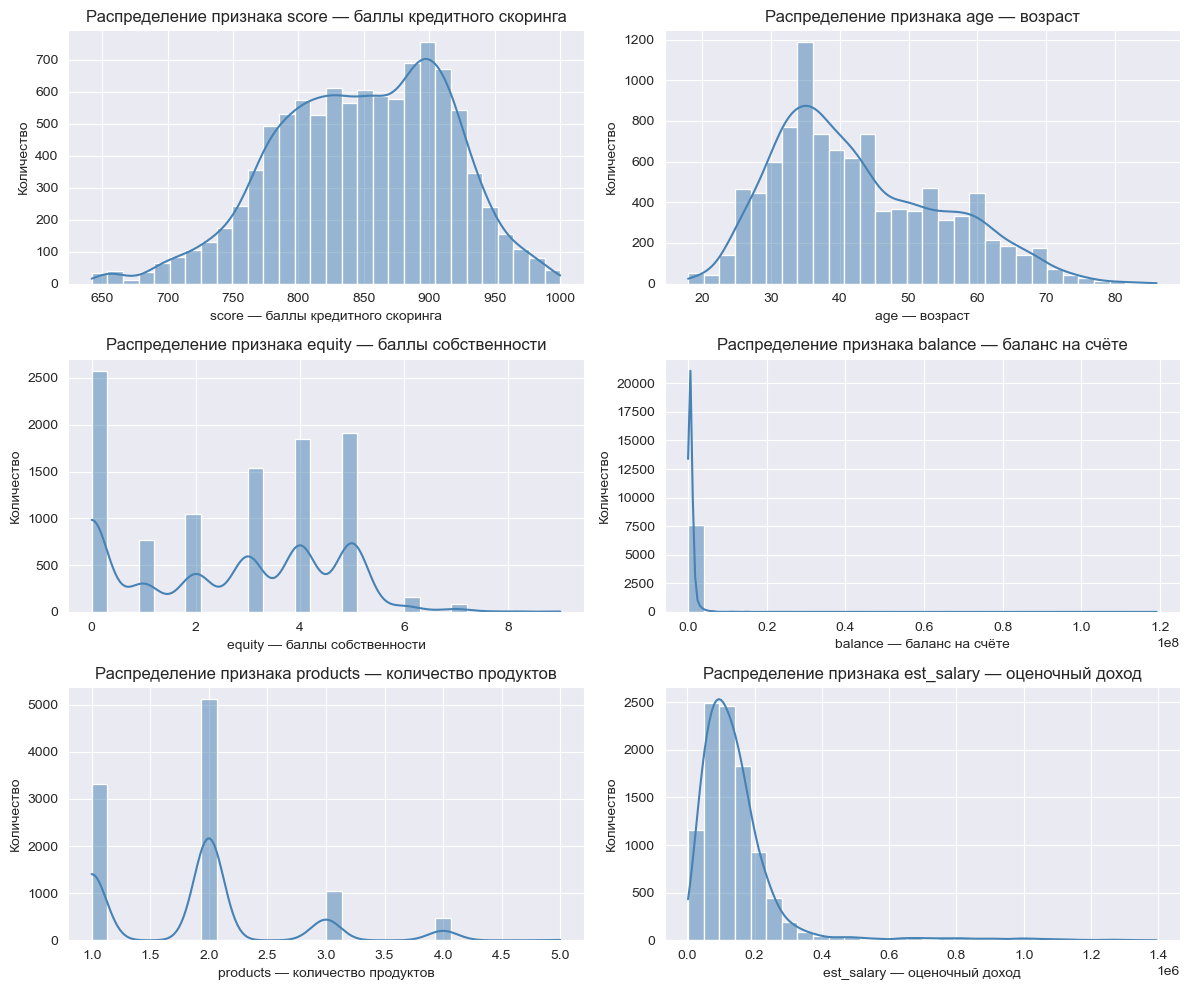

In [17]:
# добавим словарь с расшифровками
col_titles = {
    'score': 'score — баллы кредитного скоринга',
    'age': 'age — возраст',
    'equity': 'equity — баллы собственности',
    'balance': 'balance — баланс на счёте',
    'products': 'products — количество продуктов',
    'est_salary': 'est_salary — оценочный доход'
}

# список названий числовых признаков, по которым будет выполняться анализ
num_cols = ['score', 'age', 'equity', 'balance', 'products', 'est_salary']
n = len(num_cols)

# создаем сетку 3 строки × 2 столбца
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 10))
axes = axes.flatten()  # чтобы обращаться по индексу

# визуализация распределений числовых признаков с линией плотности (KDE) 
for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, bins=30, kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Распределение признака {col_titles[col]}')
    axes[i].set_xlabel(col_titles[col])
    axes[i].set_ylabel('Количество')

plt.tight_layout()
plt.show()

Построим для наглядности Boxplot по числовым переменным: score, age, equity, balance, products, est_salary

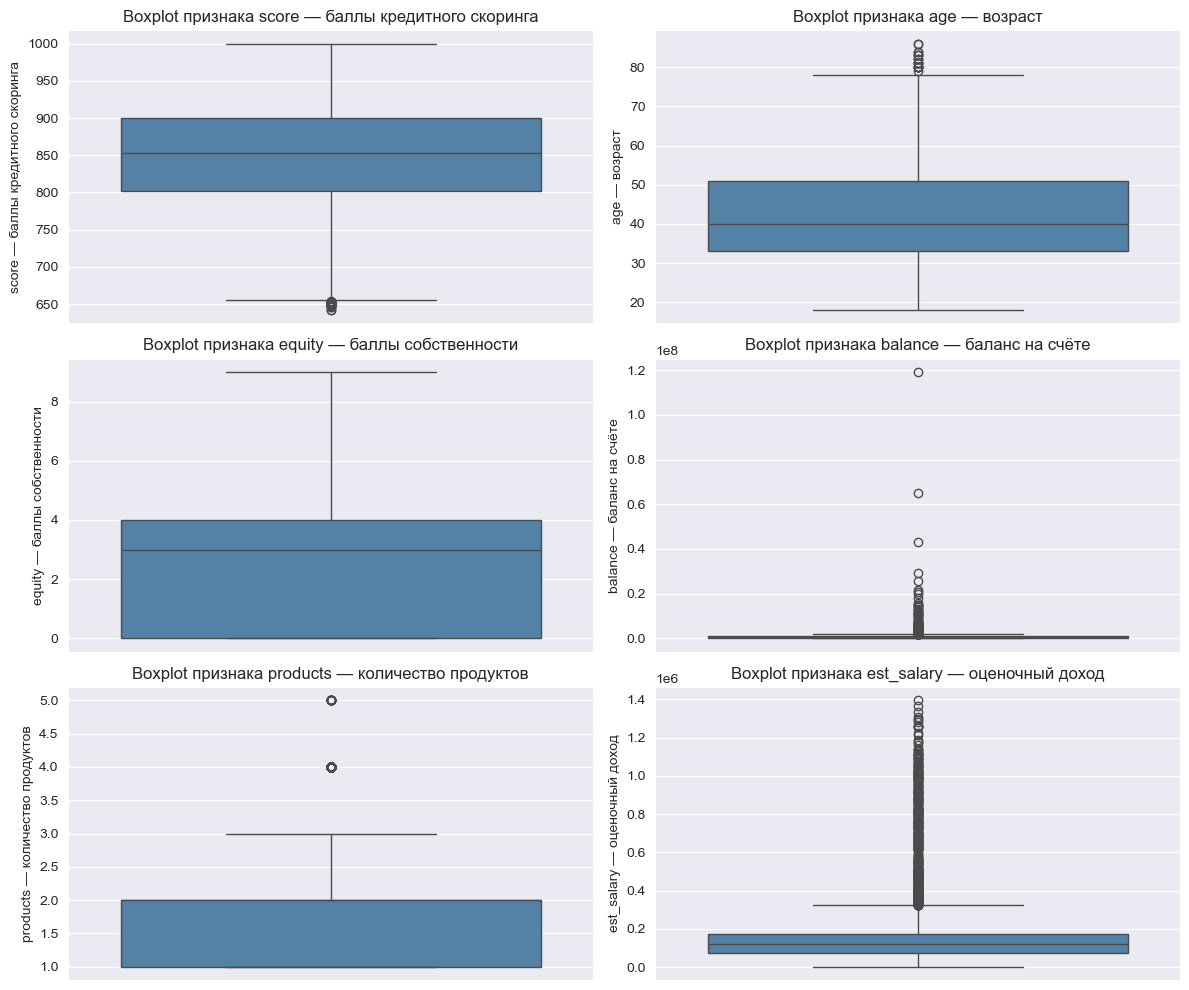

In [18]:
# сетка 3 строки × 2 столбца
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 10))
axes = axes.flatten()  # делаем массив плоским

# цикл по списку числовых признаков с индексом
for i, col in enumerate(num_cols):
    sns.boxplot(data=df, y=col, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Boxplot признака {col_titles[col]}')
    axes[i].set_ylabel(col_titles[col])

plt.tight_layout()
plt.show()


**Выводы**
- score — баллы кредитного скоринга
    - Гистограмма показывает смещение вправо: большинство клиентов имеют высокие скоринговые баллы (800–900), что говорит о низком кредитном риске.
   - Boxplot выявляет небольшое количество выбросов внизу (score < 700), но в целом распределение плотное и устойчивое.

- age — возраст
   - Распределение похоже на нормальное, с пиком в диапазоне 35–40 лет. Основной контингент — клиенты среднего возраста.
   - Boxplot показывает много выбросов среди пожилых клиентов (возраст > 75), но они составляют меньшинство.

- equity — баллы собственности
   - Дискретное распределение, с пиками на 0, 2, 4 и 5 — вероятно, это уровни имущественного положения.
   - Boxplot подтверждает это, выбросов немного, данные компактные, распределены ступенчато.

- balance — баланс на счёте
   - Гистограмма показывает крайне правостороннее распределение: большинство клиентов имеют низкий баланс, но есть единичные случаи с десятками миллионов.
   - Boxplot ярко подтверждает наличие мощных выбросов, которые сильно искажают масштаб.

- products — количество продуктов
   - Распределение многошаговое, с пиками на 1 и 2 продуктах: большинство клиентов пользуются ограниченным числом банковских услуг.
   - Boxplot показывает выбросы от клиентов с 4–5 продуктами, но они редки.

- est_salary — оценочный доход
   - Гистограмма также показывает асимметрию: большинство клиентов имеют доход до 300 тыс, с единичными случаями дохода более 1 млн.
   - Boxplot подтверждает огромное количество выбросов сверху — доход сильно варьируется, особенно у высокодоходных клиентов.

#### Сравнение форм распределений в разрезе churn

Построим гистограммы распределений числовых значений в зависимости от оттока клиентов: score — баллы кредитного скоринга, age — возраст, equity — количество баллов собственности, balance — баланс на счёте, products — количество продуктов, которыми пользуется клиент, est_salary — оценочный доход клиента  

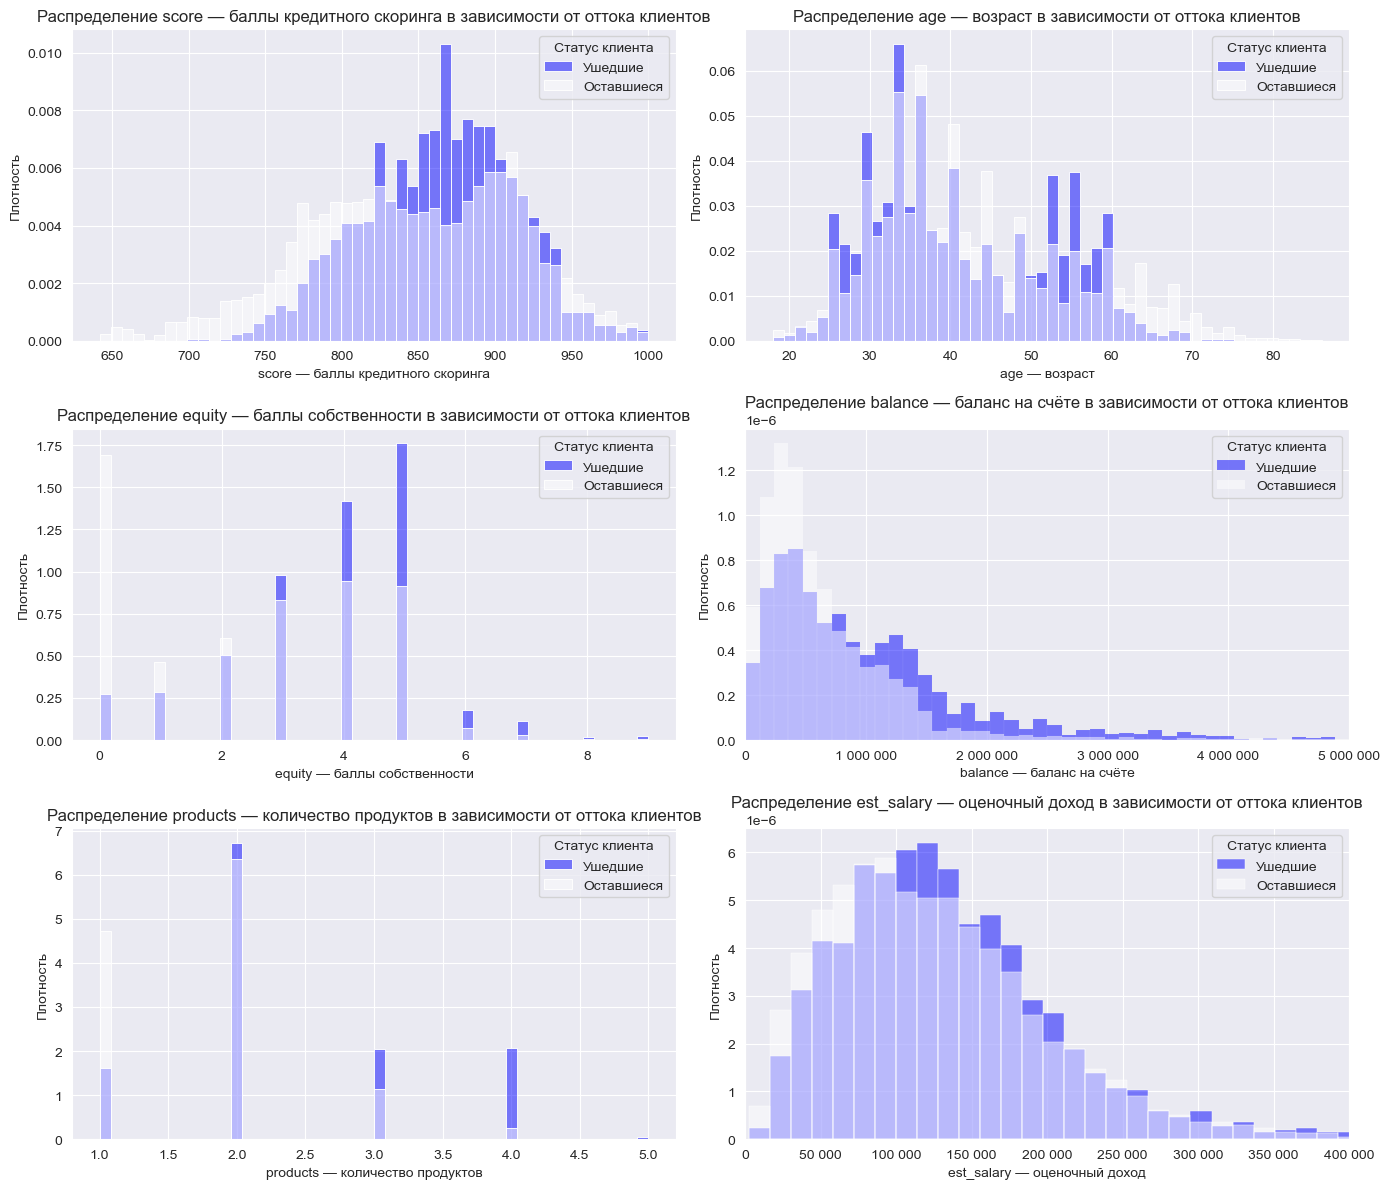

In [19]:
# создание сетки 3x2 для размещения графиков
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12))  # создаём 6 графиков на сетке 3×2
axes = axes.flatten()  # преобразуем двумерный массив осей в одномерный для удобства перебора

# цикл по всем числовым признакам
for i, col in enumerate(num_cols):
    ax = axes[i]  # текущая ось (подграфик)

    # увеличим количество корзин (bins) для признаков с большим разбросом
    if col == 'balance': 
        bins = 1000  # для balance — высокая детализация
    elif col == 'est_salary': 
        bins = 100   # для est_salary — умеренная детализация
    else: 
        bins = 50    # для остальных признаков

    # построение гистограммы с плотностью по группам оттока
    sns.histplot(
        data=df,
        x=col,
        hue='churn',            # раскраска по статусу клиента (отток / нет)
        stat='density',         # нормировка по плотности
        common_norm=False,      # нормировка отдельно для каждой группы
        bins=bins,              # количество корзин (настраивается выше)
        palette='flag',         # цветовая палитра
        ax=ax                   # размещение на текущей оси
    )
    
    # оформление графика
    ax.set_title(f'Распределение {col_titles[col]} в зависимости от оттока клиентов')
    ax.set_xlabel(col_titles[col])    # подпись оси X
    ax.set_ylabel('Плотность')        # подпись оси Y
    ax.legend(title='Статус клиента', labels=['Ушедшие', 'Оставшиеся'])  # легенда

    # ограничим ось X и форматируем подписи для balance
    if col == 'balance':
        ax.set_xlim(0, 5_000_000)
        ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', ' ')))  # формат с пробелами

    # ограничим ось X и форматируем подписи для est_salary
    elif col == 'est_salary':
        ax.set_xlim(0, 400_000)
        ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', ' ')))

# корректировка отступов между графиками
plt.tight_layout()
plt.show()  # отображение графиков


Построим гистограммы для категориальных переменных

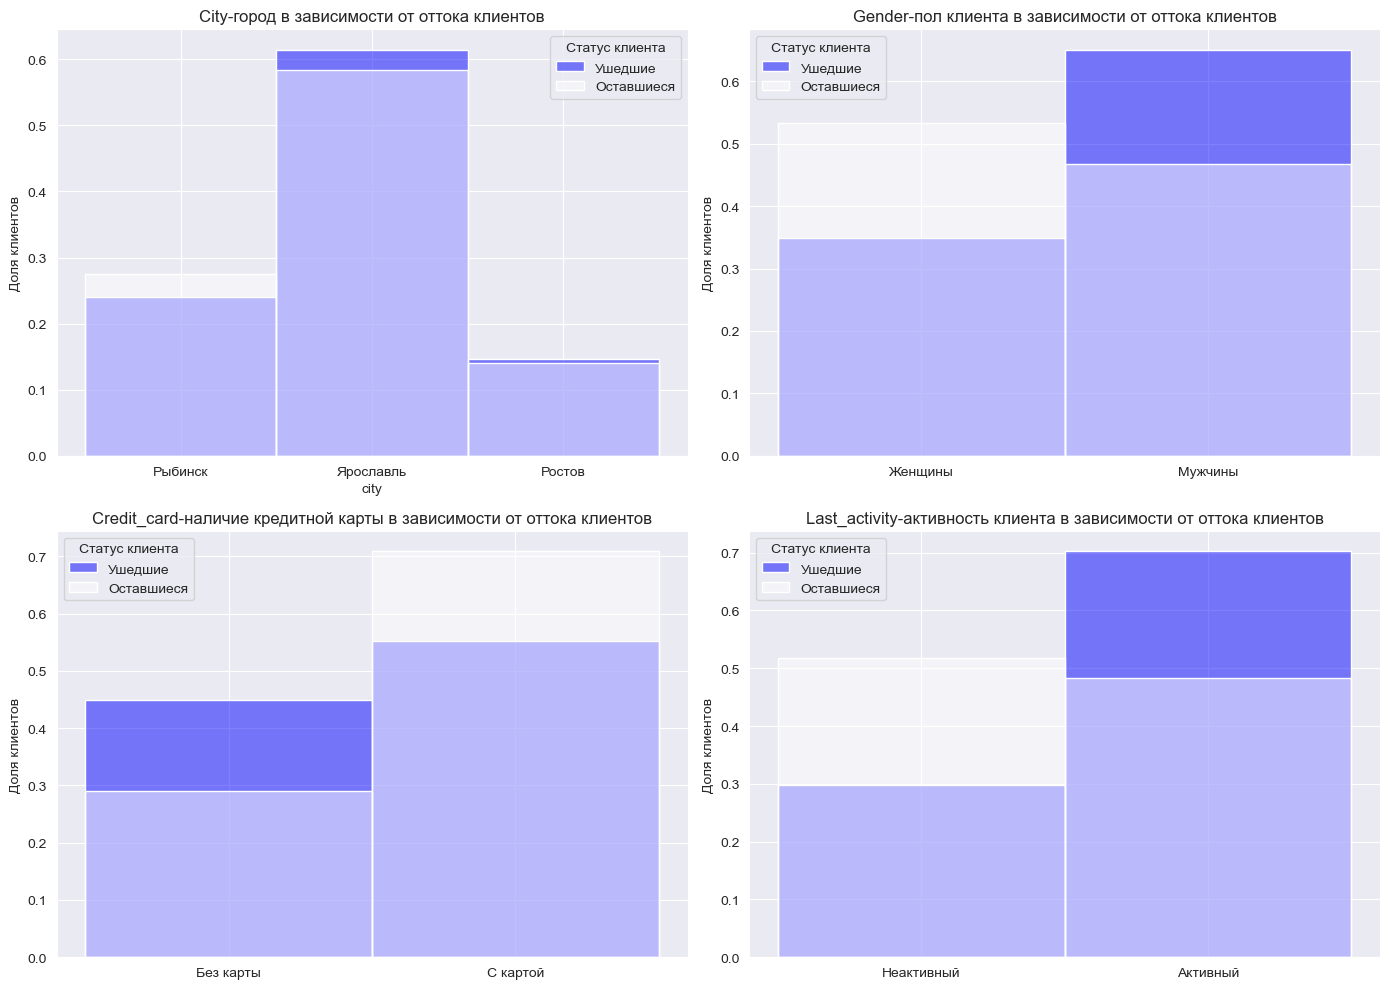

In [20]:
# список категориальных переменных
cat_cols = ['city', 'gender', 'credit_card', 'last_activity']

# подписи
label_maps = {
    'credit_card': ['Без карты', 'С картой'],
    'last_activity': ['Неактивный', 'Активный'],
    'gender': ['Женщины', 'Мужчины']
}

# расшифровки признаков для заголовков
col_desc = {
    'credit_card': 'credit_card-наличие кредитной карты',
    'last_activity': 'last_activity-активность клиента',
    'city': 'city-город',
    'gender': 'gender-пол клиента'
}

# создаём сетку под графики
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

# строим графики
for i, col in enumerate(cat_cols):
    ax = axes[i]

    sns.histplot(
        data=df,
        x=col,
        hue='churn',
        stat='density',
        common_norm=False,
        palette='flag',
        discrete=True, # так как категориальные переменные
        ax=ax
    )

    # заголовок с расшифровкой
    ax.set_title(f'{col_desc.get(col, col).capitalize()} в зависимости от оттока клиентов')
    ax.set_ylabel('Доля клиентов')
    
    # установка подписей по оси X
    if col in label_maps:
        ax.set_xticks([0, 1])
        ax.set_xticklabels(label_maps[col])
        ax.set_xlabel('')
    else:
        ax.set_xlabel(col)

    # легенда
    ax.legend(title='Статус клиента', labels=['Ушедшие', 'Оставшиеся'])

plt.tight_layout()
plt.show()


**Выводы**
- 

**Выводы**
- На основании анализа распределений и плотностей оттока, можно выделить числовые интервалы с повышенным риском ухода клиентов:
    - Баллы кредитного скоринга (score) - от 840 до 900
    - Возраст (age) - от 25 до 35 лет и от 50 до 60 лет
    - Баллы собственности (equity) - от 3 до 7
    - Баланс на счёте (balance) - от 800 000 до 4 000 000
    - Количество продуктов (products) - от 2 до 4
    - Оценочный доход (est_salary) - от 100 000 до 210 000

-  Среди категориальных переменных можно выделить следующие высокоотточные сегменты:
     - Город Ярославль (city = Ярославль)
     - Мужчины (gender = М)
     - Без карты (credit_card = 0)
     - Активный клиент (last_activity = 1)
       

| Числовой признак      | Отточный интервал               |
| ------------ | ------------------------------- |
| `score`      | от **840** до **900**           |
| `age`        | **25–35 лет** и **50–60 лет**   |
| `equity`     | от **3** до **7**               |
| `balance`    | от **800,000** до **4,000,000** |
| `products`   | от **2** до **4**               |
| `est_salary` | от **100,000** до **210,000**   |

| Категориальный признак         | Отточное значение   |
| --------------- | ------------------- |
| `city`          | **Ярославль**       |
| `gender`        | **Мужчины** (`М`)        |
| `credit_card`   | **Нет карты** (`0`) |
| `last_activity` | **Активный** (`1`)  |


### Портрет клиента с оттоком и без

#### Общие характеристики

Рассмотрим доли клиентов оставшихся и ушедших

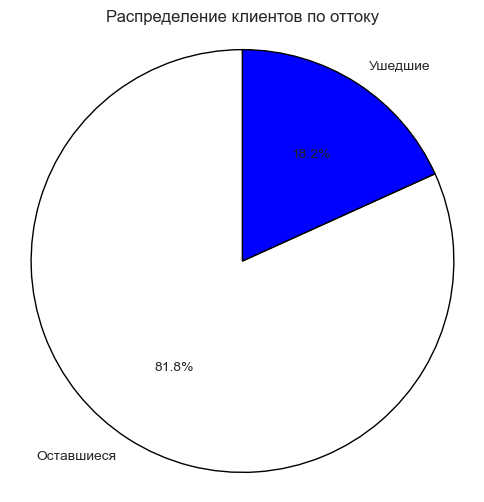

,Статус,Количество клиентов,Доля (%)
0,Оставшиеся,8155,81.8
1,Ушедшие,1818,18.2


In [21]:
# подсчёт churn
churn_counts = df['churn'].value_counts().sort_index()
labels = ['Оставшиеся', 'Ушедшие']
colors = ['#ffffff', '#0000ff']

# диаграмма
plt.figure(figsize=(6, 6))
plt.pie(
    churn_counts,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'edgecolor': 'black'}
)
plt.title('Распределение клиентов по оттоку')
plt.axis('equal')
plt.show()


# подсчёт и доли
churn_percent = (churn_counts / churn_counts.sum() * 100).round(1)

# таблица
summary_table = pd.DataFrame({
    'Статус': ['Оставшиеся', 'Ушедшие'],
    'Количество клиентов': churn_counts.values,
    'Доля (%)': churn_percent.values
})

# Отображение таблицы отдельно
summary_table

**Выводы**
- Большинство клиентов остаются в банке:
    - 81.8% клиентов — это лояльные (остались).
    - 18.2% — ушли (churn).
 - Отток не является массовым, но:
    - Почти 1 из 5 клиентов уходит, что является значимым для бизнеса.
    - Это повод проанализировать причины и провести профилактику оттока.

Рассмотрим клиентов в разрезе пол/возраст по всем/оставшихся/ушедших

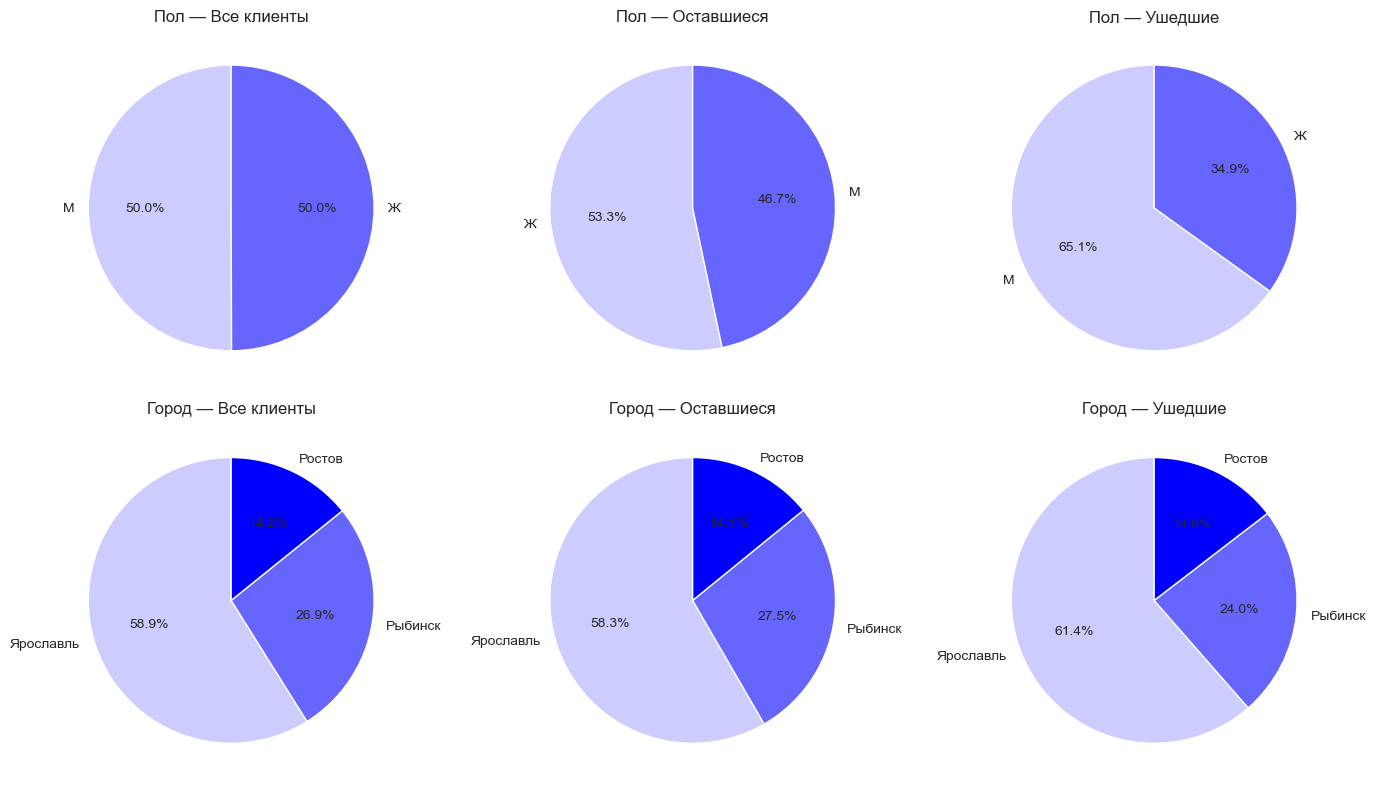

In [22]:
# цвета: оттенки синего
colors = ['#ccccff', '#6666ff', '#0000ff', '#3333cc', '#000066']

# подгруппы по оттоку
groups = {
    'Все клиенты': df,
    'Оставшиеся': df[df['churn'] == 0],
    'Ушедшие': df[df['churn'] == 1]
}

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(14, 8))

# первая строка: пол, вторая — города
for col_idx, (group_name, group_df) in enumerate(groups.items()):
    # пол
    gender_counts = group_df['gender'].value_counts()
    axes[0, col_idx].pie(
        gender_counts,
        labels=gender_counts.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=colors[:len(gender_counts)]
    )
    axes[0, col_idx].set_title(f'Пол — {group_name}')

    # город
    city_counts = group_df['city'].value_counts()
    axes[1, col_idx].pie(
        city_counts,
        labels=city_counts.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=colors[:len(city_counts)]
    )
    axes[1, col_idx].set_title(f'Город — {group_name}')

plt.tight_layout()
plt.show()


**Выводы**
- Основное отличие между ушедшими и оставшимися — гендер.

- Мужчины гораздо чаще покидают банк, чем женщины.

- Город не оказывает сильного влияния на отток.

#### Описательная статистика по группам

In [23]:
# разделим выборки
churned = df[df['churn'] == 1]
stayed = df[df['churn'] == 0]

# описательная статистика
summary = pd.concat(
    [stayed.describe().T, churned.describe().T], 
    axis=1, 
    keys=['Оставшиеся', 'Ушедшие']
)

# округляем и выводим
display(summary[['Оставшиеся', 'Ушедшие']].round(1))

Оставшиеся                                                    \
                   count      mean        std      min       25%       50%   
user_id           8155.0  171928.1    33329.0  95384.0  143046.0  173142.0   
score             8155.0     845.4       68.0    642.0     796.0     848.0   
age               8155.0      43.0       12.4     18.0      34.0      40.0   
equity            8155.0       2.4        2.0      0.0       0.0       3.0   
balance           5889.0  733031.6  1953952.5      0.0  279654.7  475410.1   
products          8155.0       1.8        0.7      1.0       1.0       2.0   
credit_card       8155.0       0.7        0.5      0.0       0.0       1.0   
last_activity     8155.0       0.5        0.5      0.0       0.0       0.0   
est_salary        8155.0  147674.6   142684.4   2546.3   73445.6  118227.6   
churn             8155.0       0.0        0.0      0.0       0.0       0.0   

                                     Ушедшие                                 \
                    75%          max   count       mean        std      min   
user_id        201160.5     229145.0  1818.0   170992.8    35296.7  94561.0   
score             900.0       1000.0  1818.0      863.4       49.6    706.0   
age                51.0         86.0  1818.0       41.4       11.1     18.0   
equity              4.0          9.0  1818.0        3.8        1.6      0.0   
balance        853826.4  119113552.0  1806.0  1134458.2  2034445.5      6.0   
products            2.0          5.0  1818.0        2.4        0.9      1.0   
credit_card         1.0          1.0  1818.0        0.6        0.5      0.0   
last_activity       1.0          1.0  1818.0        0.7        0.5      0.0   
est_salary     173960.9    1395064.4  1818.0   148357.5   122932.0  10880.3   
churn               0.0          0.0  1818.0        1.0        0.0      1.0   

                                                          
                    25%       50%        75%         max  
user_id        141302.5  170638.5   201412.8    229058.0  
score             828.0     866.0      898.0      1000.0  
age                32.0      39.0       52.0        75.0  
equity              3.0       4.0        5.0         9.0  
balance        387482.2  783908.9  1348127.6  64866210.2  
products            2.0       2.0        3.0         5.0  
credit_card         0.0       1.0        1.0         1.0  
last_activity       0.0       1.0        1.0         1.0  
est_salary      83285.7  125408.9   176017.8   1263028.5  
churn               1.0       1.0        1.0         1.0

**Выводы**
-  Score — баллы кредитного скоринга.
   -  Среднее значение выше у ушедших клиентов (863 vs 845). Но распределение у оставшихся шире, с большим разбросом.
   - Вывод: несмотря на более высокий средний балл, высокая вариативность у оставшихся может указывать на смешанный риск-профиль. Балл сам по себе не является определяющим фактором оттока.

- Age — возраст
  - Ушедшие клиенты в среднем помладше (41.4 vs 43.0).
   - Вывод: возраст имеет умеренное влияние — больше клиентов уходит в возрасте 35-50 лет.

- Equity — баллы собственности
   - Ушедшие клиенты имеют больше активов/собственности (среднее: 3.8 vs 2.4).
   - Вывод: клиенты с большей собственностью чаще уходят — возможно, они более финансово грамотны и склонны менять банк.

- Balance — баланс на счёте
   - Ушедшие имеют значительно больший средний баланс (1.13 млн против 733 тыс).
   - Распределение крайне смещено с выбросами.
   - Вывод: клиенты с крупными суммами склонны уходить. Это важный риск — уходит ценный сегмент.

- Products — количество продуктов
   - Ушедшие пользовались большим количеством банковских продуктов (2.4 vs 1.8).
   - Вывод: уходят клиенты с высокой вовлечённостью, возможно, из-за неудовлетворённости сервисом.

- Credit_card и last_activity
   - Различия минимальны. Обе группы имеют схожую активность и долю карт.
   - Вывод: данные признаки не являются определяющими при оттоке.

- Est_salary — оценочный доход
   - Средний доход у ушедших выше: 148 тыс. против 147 тыс. (разница мала).
   - Вывод: доход не оказывает ярко выраженного влияния.

#### Визуализация различий

Для того, чтобы быстро и наглядно выявить закономерности, отличия и аномалии в данных, используем визуализацию при помощи boxplot по всем ключевым числовым признакам (score, age, balance, equity, products, est_salary).

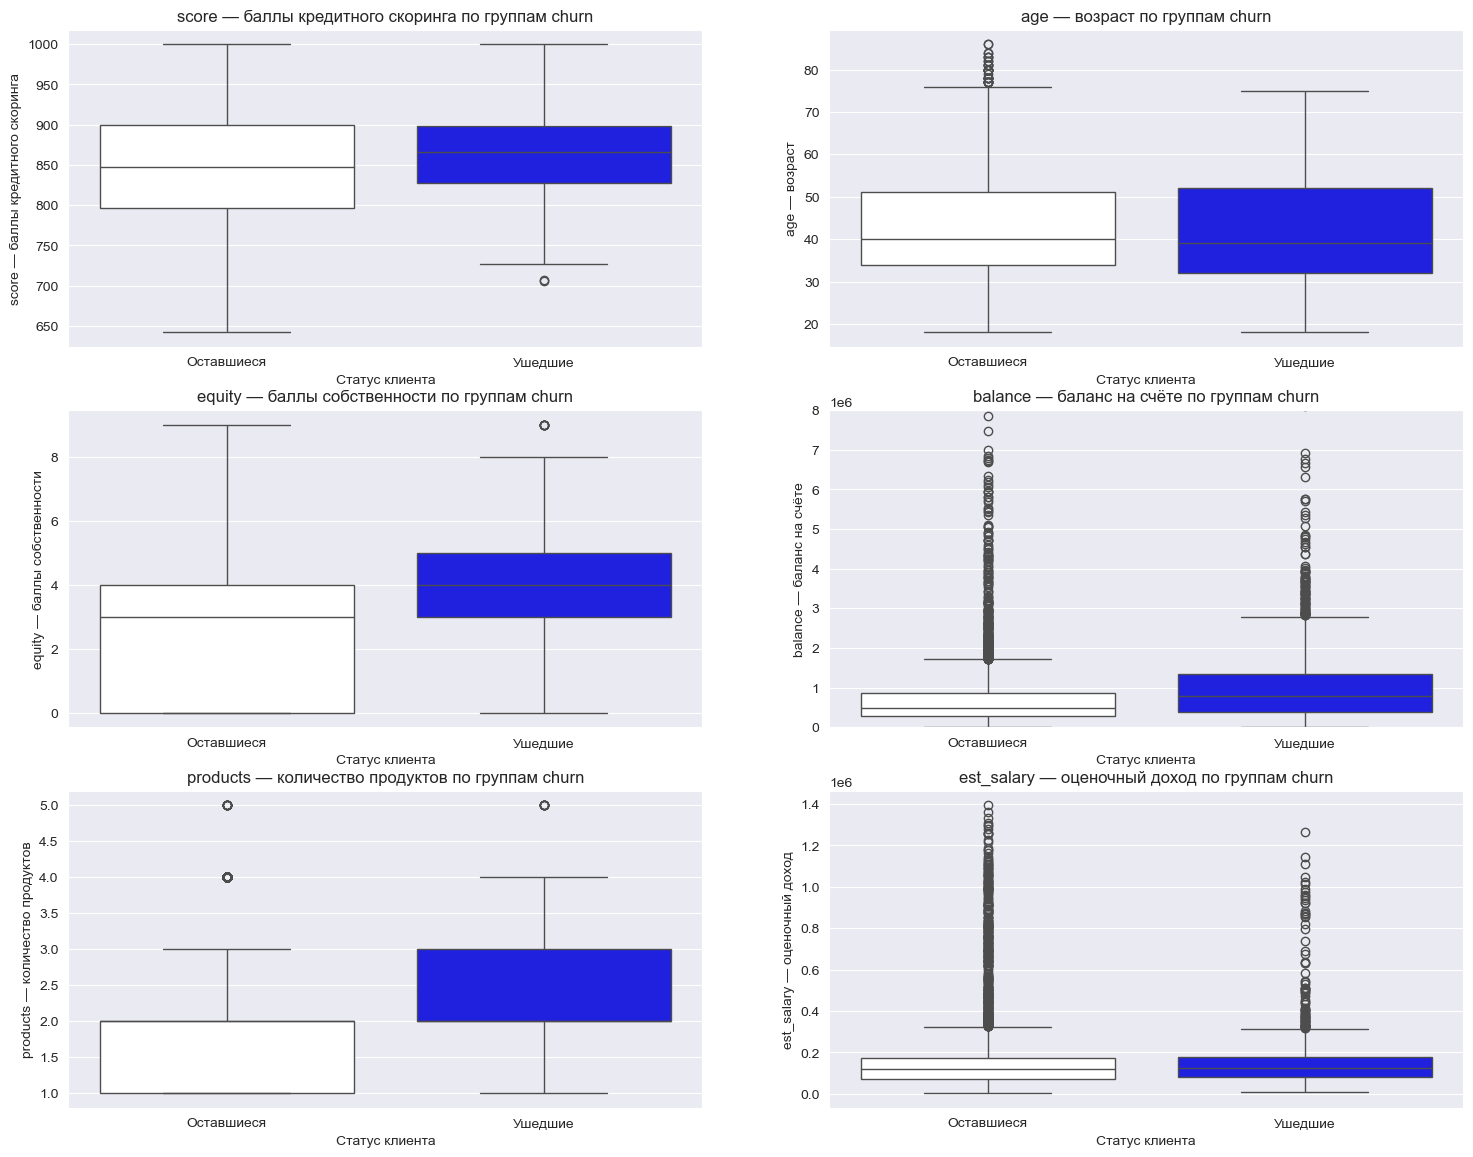

In [24]:
# создание фигуры с сеткой 3×2 для размещения boxplot-графиков
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(18, 14))
axes = axes.flatten()  # Преобразуем массив осей в одномерный список

# построение boxplot для каждого числового признака по группам churn
for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='churn', y=col, palette='flag', ax=axes[i])
    axes[i].set_title(f'{col_titles[col]} по группам churn')  # заголовок графика
    axes[i].set_xlabel('Статус клиента')
    axes[i].set_ylabel(col_titles[col])
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Оставшиеся', 'Ушедшие'])  # подписи групп по оси X

    # масштабирование оси Y для признака balance (чтобы не было выбросов)
    if col == 'balance':
        axes[i].set_ylim(0, 8_000_000)


**Выводы**
- Баланс и число продуктов — выше у клиентов с оттоком.
- Equity (баллы собственности) — тоже выше у ушедших.
- Score немного выше у ушедших, что неожиданно.
- Возраст — у ушедших преобладают клиенты 35–50 лет.
- est_salary (доход) — распределения схожи, но медиана чуть выше у ушедших.
- Уходят более обеспеченные, старшие, вовлечённые клиенты с несколькими продуктами и высоким балансом. Это тревожный сигнал: банк теряет ценные сегменты, и нужно сфокусироваться на удержании этих групп.

#### Выделение характерных признаков и аномалий

| Признак         | Оставшиеся (churn = 0) | Ушедшие (churn = 1) |
| --------------- | ---------------------- | ------------------- |
| Средний возраст | 43.0                   | 41.4                |
| Средний score   | 845.4                  | 863.4               |
| Средний баланс  | 733 тыс. ₽             | **1.13 млн ₽**   |
| Средний доход   | 147 тыс. ₽             | **148 тыс. ₽**      |
| Среднее equity  | 2.4                    | **3.8**          |
| Продуктов       | 1.8                    | **2.4**         |


**Выводы**
- Характерные признаки клиентов с оттоком:
   - Имеют больше продуктов, выше баланс и высокие баллы собственности.

   - Часто в возрасте 35–50 лет.

   - Несмотря на высокий score, уходят — возможно, более финансово активны и требовательны.

- Аномалии:
   - Очень высокие значения по balance и est_salary — возможны выбросы.

### Корреляционный анализ

#### Корреляционный анализ по Pearson

Построим тепловую карту корреляции по коэффициенту Пирсона 

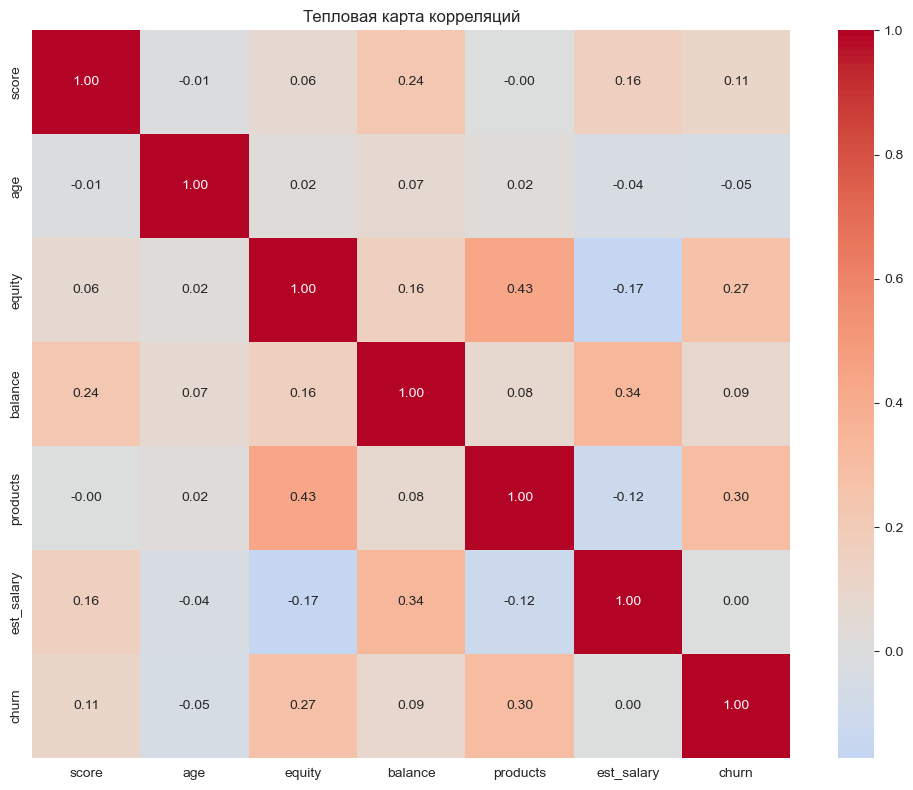

In [25]:
# построим тепловую карту корреляций для числовых признаков
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols + ['churn']].corr(), cmap='coolwarm', annot=True, fmt=".2f", center=0)
plt.title('Тепловая карта корреляций')
plt.tight_layout()
plt.show()

Выделим только корреляцию признаков с оттоком (churn) по Пирсону

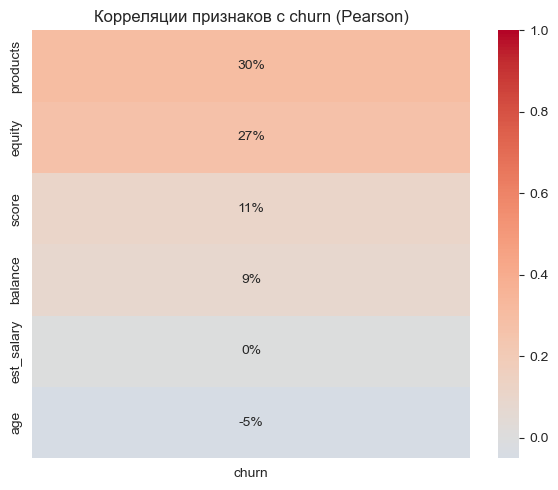

In [26]:
# посчитаем корреляции с churn
corr_matrix = df[num_cols + ['churn']].corr()
churn_corr = corr_matrix[['churn']].drop('churn').sort_values(by='churn', ascending=False)

# визуализируем один столбец
plt.figure(figsize=(6, 5))
sns.heatmap(
    churn_corr,
    annot=True,
    fmt=".0%",
    cmap='coolwarm',
    center=0, vmax=1,
    cbar=True
)
plt.title("Корреляции признаков с churn (Pearson)", fontsize=12)
plt.tight_layout()
plt.show()

**Выводы**
- Количество продуктов (products) — самый значимый фактор из числовых: чем больше продуктов у клиента, тем выше вероятность его оттока. Возможное объяснение: клиенты, у которых много продуктов, могут быть перегружены или менее удовлетворены.
- Собственность (equity) также умеренно коррелирует с оттоком: чем выше баллы собственности, тем выше вероятность ухода клиента.
- Оценочный доход (est_salary) и возраст (age) — не оказывают влияния на churn (корреляция ≈ 0).
- Баланс (balance) и баллы кредитного скоринга (score) хоть и положительно коррелируют с churn, но слабо.

#### Корреляционный анализ по Phik

In [27]:
#!pip install phik

Построим φK-матрицу

interval columns not set, guessing: ['score', 'age', 'equity', 'balance', 'products', 'credit_card', 'last_activity', 'est_salary', 'churn']


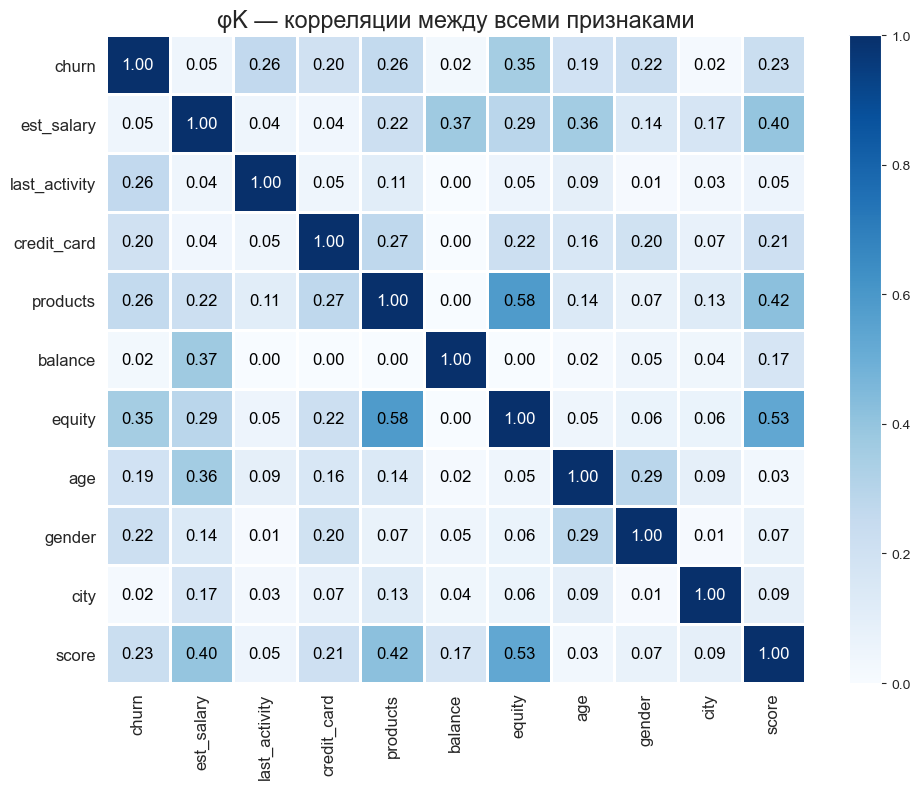

In [28]:
# удалим неинформативные признаки
df_phik = df.drop(columns=['user_id'])

# φK-матрица
phik_matrix = df_phik.phik_matrix()

# построение полной тепловой карты
plot_correlation_matrix(
    phik_matrix.values,
    x_labels=phik_matrix.columns,
    y_labels=phik_matrix.index,
    vmin=0, vmax=1,
    color_map="Blues",
    title="φK — корреляции между всеми признаками",
    fontsize_factor=1.2,
    figsize=(10, 8)
)
plt.tight_layout()
plt.show()



Построим только по столбцу churn

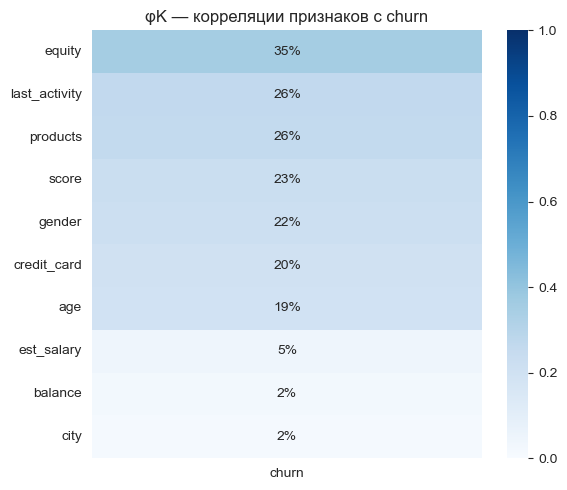

In [29]:
# оставим только столбец churn и отсортируем по значению
churn_corr = phik_matrix[['churn']].drop(index='churn').sort_values(by='churn', ascending=False)

# визуализация
plt.figure(figsize=(6, 5))
sns.heatmap(
    churn_corr,
    annot=True,
    fmt=".0%",
    cmap="Blues",
    vmin=0, vmax=1,
    cbar=True
)
plt.title("φK — корреляции признаков с churn", fontsize=12)
plt.tight_layout()
plt.show()

**Выводы**
- Собственность (equity) — самая сильная связь (35%): чем выше баллы собственности, тем выше риск оттока.
- Активность клиента (last_activity) и количество продуктов (products) — по 26%: меньше активности и больше продуктов — выше вероятность ухода.
- Баллы кредитного скоринга (score), gender(пол), credit_card(наличие кредитной карты), age(возраст) — умеренная связь (19–23%).
- Оценочный доход (est_salary), balance(баланс на счете), city (город)— слабая или почти отсутствует (≤5%).

#### Отбор признаков с сильной связью

**Выводы и рекомендации**

- Анализ по двум метрикам (Pearson и φK) показывает, что наибольшую корреляцию с оттоком демонстрируют:

   - количество продуктов (products): по Pearson (30%) и Phik (26%) — чем больше продуктов у клиента, тем выше вероятность оттока.
   - собственность (equity): Pearson (27%) и Phik (35%) — клиенты с высокими баллами собственности чаще уходят
   - активность клиента (last_activity): Phik (26%) — менее активные клиенты чаще уходят.
- Эти признаки стоит использовать в качестве основных факторов риска churn при формировании стратегий удержания клиентов.
- Рекомендуется сфокусироваться на клиентах с высокой собственностью, большим числом продуктов и низкой активностью — это ключевые зоны риска.

<a id="data_section4"></a>
## Шаг 4. Проверка статистических гипотез

### Гипотеза 1: Средний доход клиентов, ушедших и оставшихся, различается.

- Проверим гипотезы
   - H₀ (нулевая гипотеза): ссредний доход клиентов, ушедших и оставшихся, одинаковый
   - H₁ (альтернатива): средние доходы различаются.
- Для проверки гипотезы применим t-тест Стьюдента для независимых выборок. Он позволяет определить, есть ли статистически значимое различие между средними значениями двух групп — в данном случае: клиентов с оттоком (churn = 1) и оставшихся клиентов (churn = 0).
   - Если p-значение > 0.05, статистически значимого различия нет — доход не влияет на отток.
   - Если p-значение ≤ 0.05, различие считается значимым — доход может влиять на отток.

In [30]:
# делим данные на группы
salary_stayed = df[df['churn'] == 0]['est_salary']
salary_left = df[df['churn'] == 1]['est_salary']

# t-тест на равенство средних
t_stat, p_val = ttest_ind(salary_stayed, salary_left, equal_var=False)

print(f"t-статистика: {t_stat:.2f}, p-значение: {p_val:.4f}")


t-статистика: -0.21, p-значение: 0.8355


**Выводы**
- t-статистика: –0.21 и p-значение: 0.8355
- Так как p > 0.05, нет статистически значимых различий в среднем доходе между ушедшими и оставшимися клиентами. Следовательно, мы не отвергаем нулевую гипотезу: средний доход у обеих групп одинаковый.
- Доход (est_salary) не влияет на вероятность оттока.

### Гипотеза 2: Наличие кредитной карты влияет на вероятность оттока

- Проверим гипотезы:
   - H₀(нулевая гипотеза): наличие кредитной карты не связано с оттоком (переменные независимы)
   - H₁(альтернативная гипотеза): между наличием кредитной карты и оттоком есть статистическая связь.
- Для проверки используем критерий хи-квадрат Пирсона, который оценит, зависит ли вероятность оттока от наличия кредитной карты. Применим к двум категориальным признакам: credit_card (0 — нет карты, 1 — есть), churn (0 — остался, 1 — ушёл).
   - p-значение > 0.05, отклонять H₁ нельзя: связь не подтверждена, карта не влияет на отток.
   - p-значение ≤ 0.05, отклоняем H₀: есть статистическая связь, наличие карты влияет на отток.

In [31]:
# создаем таблицу сопряжённости
contingency_table = pd.crosstab(df['credit_card'], df['churn'])

# срименяем χ²-тест
chi2, p_val, dof, expected = chi2_contingency(contingency_table)

# вывод результатов
print(f"χ²-статистика: {chi2:.2f}, p-значение: {p_val}")

χ²-статистика: 168.14, p-значение: 1.8875596706050456e-38


Чтобы корректно интерпретировать, посмотрим, как распределены клиенты по наличию кредитной карты и оттоку

In [32]:
# Построим таблицу сопряжённости без переименования
contingency_table = pd.crosstab(df['credit_card'], df['churn'], margins=True)

# Получим значения из таблицы
no_card_churn = contingency_table.loc[0, 1]
no_card_total = contingency_table.loc[0, 'All']
with_card_churn = contingency_table.loc[1, 1]
with_card_total = contingency_table.loc[1, 'All']

# Расчёт долей
no_card_churn_rate = no_card_churn / no_card_total * 100
with_card_churn_rate = with_card_churn / with_card_total * 100

# Вывод
print(f"Доля оттока среди клиентов БЕЗ карты: {no_card_churn_rate:.1f}%")
print(f"Доля оттока среди клиентов С картой: {with_card_churn_rate:.1f}%")



Доля оттока среди клиентов БЕЗ карты: 25.6%
Доля оттока среди клиентов С картой: 14.8%


**Выводы и рекомендации**
- Значение χ² = 168.14, p-значение 1.8875596706050456e-38 — статистически значимое. Нулевая гипотеза (H₀) о независимости отвергается и соответсвенно принимаем альтернативную гипотезу о том, что между наличием кредитной карты и оттоком есть статистическая связь.
- Доля оттока среди клиентов без карты — 25.6%, среди клиентов с картой — 14.8%. Наличие кредитной карты связано с более низким риском оттока. Клиенты без карты уходят почти в 2 раза чаще, чем те, у кого она есть.
- Рекомендуем стимулировать оформление кредитных карт среди клиентов. Это может быть реализовано через персональные предложения, упрощённые условия получения или бонусные программы — как способ повысить вовлечённость и снизить вероятность оттока.

<a id="data_section5"></a>
## Шаг 5. Промежуточный итог

**На основе описательной статистики, корреляционного анализа (Pearson и φK), а также проверок гипотез можно выделить ключевые признаки, влияющие на отток:**
 - Количество продуктов (products) – главный числовой фактор по Пирсону. Чем больше продуктов у клиента, тем выше риск оттока.
 - Собственность (equity) – сильнейшая корреляция по φK. Повышенные баллы собственности также связаны с более высокой вероятностью ухода.
 - Активность клиента (last_activity) – менее активные пользователи чаще уходят.
 - Наличие кредитной карты (credit_card) – значимо снижает риск оттока (по χ²-тесту).
 - Баллы скоринга (score) и пол (gender) – оказывают умеренное влияние.
 - Возраст(age) и доход(est_salary) – не оказывают существенного влияния.

**Рекомендации:**
Для снижения оттока стоит обратить внимание на перегруженных клиентов с множеством продуктов, усиливать удержание среди неактивных, а также развивать программы, мотивирующие заведение кредитных карт.

<a id="data_section6"></a>
## Шаг 6. Сегментация

Сформируем 5 сегментов по логике query() с комбинированными условиями.

Выберем приоритетные сегменты с высоким риском и бизнес-потенциалом:
- отток ≥ 30%,
- размер сегмента от 500 до 2000 клиентов.

In [33]:
# условия для сегментации клиентов — числовые и категориальные признаки с повышенным риском оттока
conditions = [
    "(score >= 840 and score <= 900)",
    "(age >= 25 and age <= 35)",
    "(age >= 50 and age <= 60)",
    "(equity >= 3 and equity <= 7)",
    "(balance >= 800000 and balance <= 4000000)",
    "(products >= 2 and products <= 4)",
    "(est_salary >= 100000 and est_salary <= 210000)",
    "(city == 'Ярославль')",
    "(gender == 'М')",
    "(credit_card == 0)",
    "(last_activity == 1)"
]

results_debug = [] # список для хранения подходящих сегментов


# перебор всех комбинаций по 2 условиям
for comb in combinations(conditions, 2):
    query_str = " and ".join(comb)           # объединяем два условия через AND
    segment = df.query(query_str)            # фильтруем клиентов по условиям
    size = len(segment)                      # считаем размер сегмента
    if 500 <= size <= 2000:                  # отбираем сегменты с нужной численностью
        churn_rate = segment['churn'].mean() # вычисляем уровень оттока
        if churn_rate > 0.3:                 # отбираем только высокоотточные сегменты
            results_debug.append({
                'Условие': query_str,
                'Размер': size,
                'Отток': round(churn_rate * 100, 1)  # отток в процентах
            })

# показываем полную строку в ячейке DataFrame
pd.set_option('display.max_colwidth', None)

# создаём итоговую таблицу и сортируем по убыванию оттока
results_df = pd.DataFrame(results_debug)
display(results_df.sort_values(by='Отток', ascending=False))

,Условие,Размер,Отток
7,(age >= 25 and age <= 35) and (balance >= 800000 and balance <= 4000000),542,49.1
20,(balance >= 800000 and balance <= 4000000) and (last_activity == 1),1253,48.9
18,(balance >= 800000 and balance <= 4000000) and (gender == 'М'),1211,46.1
11,(age >= 50 and age <= 60) and (balance >= 800000 and balance <= 4000000),548,45.4
19,(balance >= 800000 and balance <= 4000000) and (credit_card == 0),1076,42.7
2,(score >= 840 and score <= 900) and (balance >= 800000 and balance <= 4000000),920,42.3
5,(score >= 840 and score <= 900) and (last_activity == 1),1592,40.6
16,(balance >= 800000 and balance <= 4000000) and (est_salary >= 100000 and est_salary <= 210000),1281,39.9
17,(balance >= 800000 and balance <= 4000000) and (city == 'Ярославль'),1433,39.3
8,(age >= 25 and age <= 35) and (credit_card == 0),827,35.7


- **Conclusions**

- All possible customer segments were analyzed based on combinations of two features (e.g., age, balance, activity, equity, etc.).

- Only segments meeting the following criteria were selected:
  - Number of customers: 500 to 2,000  
  - Churn rate above 30%  

- The final list includes the highest-risk segments, which can be used to prioritize retention strategies.

---

- **Top 10 High-Risk Segments**

- **Young customers with high balances**
  - Condition: age 25–35 and balance from 800,000 to 4,000,000  
  - Size: 542 customers  
  - Churn rate: 49.1%  
  - Insight: young high-value customers are more likely to leave. Recommendation: offer long-term and investment products.

---

- **Active customers with high balances**
  - Condition: activity = 1, balance from 800,000 to 4,000,000  
  - Size: 1,253 customers  
  - Churn rate: 48.9%  
  - Insight: activity does not guarantee loyalty — these customers may be actively exploring alternatives or closing accounts.

---

- **Male customers with high balances**
  - Condition: gender = male, balance from 800,000 to 4,000,000  
  - Size: 1,211 customers  
  - Churn rate: 46.1%  
  - Insight: high-value male customers are particularly prone to churn — behavioral preferences should be considered.

---

- **Customers aged 50–60 with high balances**
  - Condition: age 50–60, balance from 800,000 to 4,000,000  
  - Size: 548 customers  
  - Churn rate: 45.4%  
  - Insight: pre-retirement customers may seek more stable and favorable financial conditions.

---

- **Customers without a credit card and high balances**
  - Condition: no credit card, balance from 800,000 to 4,000,000  
  - Size: 1,076 customers  
  - Churn rate: 42.7%  
  - Insight: lack of product engagement reduces customer retention — cross-selling credit cards and offering onboarding incentives is recommended.

---

- **Customers with high credit scores and high balances**
  - Condition: score 840–900, balance from 800,000 to 4,000,000  
  - Size: 920 customers  
  - Churn rate: 42.3%  
  - Insight: even financially reliable customers may churn — a personalized approach is required.

---

- **Active customers with high credit scores**
  - Condition: score 840–900, activity = 1  
  - Size: 1,592 customers  
  - Churn rate: 40.6%  
  - Insight: active and high-scoring customers require retention through premium offers.

---

- **High-income customers with high balances**
  - Condition: income 100,000–210,000, balance from 800,000 to 4,000,000  
  - Size: 1,281 customers  
  - Churn rate: 39.9%  
  - Insight: high-income customers are sensitive to service conditions — segmentation and personalized benefits are important.

---

- **Customers from Yaroslavl with high balances**
  - Condition: city = Yaroslavl, balance from 800,000 to 4,000,000  
  - Size: 1,433 customers  
  - Churn rate: 39.3%  
  - Insight: potential regional issues (service quality, product availability, or competition) require further investigation.

---

- **Young customers without a credit card**
  - Condition: age 25–35 and no credit card  
  - Size: 827 customers  
  - Churn rate: 35.7%  
  - Insight: young customers without credit products are a vulnerable segment — opportunity: introduce cashback cards and digital-focused solutions.

---

- **Key Churn Drivers**

- The main factor across most high-risk segments is a high account balance. This indicates that churn disproportionately affects the most valuable customers, making it a critical business issue.

- In several segments, active customers and those with high credit scores also show high churn rates. This challenges the assumption that engaged and reliable customers are always loyal.

- Lack of a credit card is a common feature among high-risk groups, indicating low integration into the bank’s ecosystem — fewer products make it easier for customers to leave.

- The regional factor (Yaroslavl) appears significant and may indicate local operational or competitive challenges.

- Even younger customers with strong financial indicators (balance, income, activity) show higher churn rates, suggesting a lack of personalized services or modern digital solutions.

---

- **Final Insight**

- These segments represent high-priority targets for churn reduction strategies. It is recommended to focus on retaining high-value customers, particularly those with specific behavioral and demographic characteristics.

<a id="data_section7"></a>
## Step 7. Key Findings and Recommendations

- **Key Findings**

- The churn rate is approximately 18% of the total customer base.

- Based on distribution and density analysis, the following numerical ranges are associated with higher churn risk:
  - Credit score — from 840 to 900  
  - Age — from 25 to 35 and from 50 to 60  
  - Equity — from 3 to 7  
  - Account balance — from 800,000 to 4,000,000  
  - Number of products — from 2 to 4  
  - Estimated salary — from 100,000 to 210,000  

- Among categorical variables, the following high-risk segments were identified:
  - Customers from Yaroslavl (city = Yaroslavl)  
  - Male customers (gender = M)  
  - Customers without a credit card (credit_card = 0)  
  - Active customers (last_activity = 1)  

- Based on correlation analysis (Pearson and Phik), the most significant features are:  
  **products, equity, score, last_activity, gender**

- Identified top 10 high-risk segments (churn rate above 30%) with segment sizes ranging from 500 to 2,000 customers:
  - Young customers with high balances  
  - Active customers with high balances  
  - Male customers with high balances  
  - Pre-retirement customers with high balances  
  - Customers without a credit card and high balances  
  - Customers with high credit scores and high balances  
  - Active customers with high credit scores  
  - High-income customers with high balances  
  - Customers from Yaroslavl with high balances  
  - Young customers without a credit card  

---

- **Key Churn Drivers**

    - High account balance is a common characteristic across all high-risk segments, indicating that churn affects the most valuable customers.

    - High activity and strong credit scores do not necessarily indicate loyalty — even reliable customers are likely to churn.

    - Lack of a credit card indicates weaker engagement with the bank, making such customers more likely to leave.

    - Regional factor (Yaroslavl) may indicate local issues affecting customer retention.

    - Younger customers with strong financial metrics churn more frequently, possibly due to a lack of personalized services or digital solutions.

---

- **Recommendations**

- **Retain High-Value Customers**  
High-balance customers form the core of the business but are also the most likely to churn. Recommended actions:
  - Provide personalized offers based on balance (deposits, premium cards, investment products)  
  - Implement automated triggers when customer activity declines or when account closure is initiated  

---

- **Age-Based Segmentation Strategy**  
Both younger (25–35) and older (50–60) customers are at risk, but for different reasons:
  - Younger customers: offer digital products, mobile services, and rewards for online engagement  
  - Pre-retirement customers: focus on stability, reliability, and personalized service (e.g., dedicated account manager)  

---

- **Focus on Product Value, Not Quantity**
  - Strengthen cross-selling between services  
  - Introduce premium and credit-based products  
  - Encourage bundled product usage  

---

- **Monitor Active Customers**  
Activity does not guarantee loyalty. Recommended actions:
  - Track early signs of churn (e.g., frequent transfers, declining balances)  
  - Offer proactive incentives (cashback, investment options) during periods of high activity  

---

- **Regional Strategy**  
Higher churn in Yaroslavl may indicate local challenges. Recommended actions:
  - Assess competition, service quality, and product availability in the region  
  - Launch targeted campaigns with localized offers  

---

- **Strengthen Credit Card Strategy**
  - Increase promotion of credit products through personalized offers, bundled packages, and onboarding bonuses  
  - Expanding credit card adoption can strengthen customer engagement and reduce churn risk  